### Architecture
In this experiment swin tranformer model is taken and applied on images with final head removal and single pawpularity output is added. In addition, lite augmentation is applied

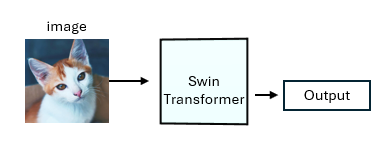

### Analysis
Swin models see the image as a set of tokens and uses multi‑head self‑attention to capture long‑range dependencies and global layout (how the pet, background, and other objects relate across the whole frame), whereas EfficientNet relies on local convolutions and pooling, which are less expressive for scene‑level images 


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# imports and config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image

main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp3_swin_256_lite")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp3"]
cfg["img_size"] = 256
cfg["aug"] = "lite"
cfg["name"] = "exp3_swin_256_lite"
TARGET = "Pawpularity"
os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp3_swin_256_lite: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[BCE]: Loss=0.6490 | ValRMSE: 18.2014
Epoch 2/10 | Fold 1 | Train[BCE]: Loss=0.6360 | ValRMSE: 18.1016
Epoch 3/10 | Fold 1 | Train[BCE]: Loss=0.6205 | ValRMSE: 18.1059
Epoch 4/10 | Fold 1 | Train[BCE]: Loss=0.6040 | ValRMSE: 19.1820
Epoch 5/10 | Fold 1 | Train[BCE]: Loss=0.5927 | ValRMSE: 18.9955
Epoch 6/10 | Fold 1 | Train[BCE]: Loss=0.5855 | ValRMSE: 19.1602
Epoch 7/10 | Fold 1 | Train[BCE]: Loss=0.5807 | ValRMSE: 19.2742
Early stopping at epoch 7
Fold 1 best RMSE: 18.1016

=== exp3_swin_256_lite: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[BCE]: Loss=0.6482 | ValRMSE: 17.9854
Epoch 2/10 | Fold 2 | Train[BCE]: Loss=0.6337 | ValRMSE: 18.0494
Epoch 3/10 | Fold 2 | Train[BCE]: Loss=0.6166 | ValRMSE: 18.8299
Epoch 4/10 | Fold 2 | Train[BCE]: Loss=0.6004 | ValRMSE: 19.4745
Epoch 5/10 | Fold 2 | Train[BCE]: Loss=0.5884 | ValRMSE: 19.2955
Epoch 6/10 | Fold 2 | Train[BCE]: Loss=0.5822 | ValRMSE: 19.4447
Early stopping at epoch 6
Fold 

In [4]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 18.1016 (n=1983)
Fold 2 OOF RMSE: 17.9854 (n=1983)
Fold 3 OOF RMSE: 17.3566 (n=1982)
Fold 4 OOF RMSE: 17.6670 (n=1982)
Fold 5 OOF RMSE: 18.1945 (n=1982)


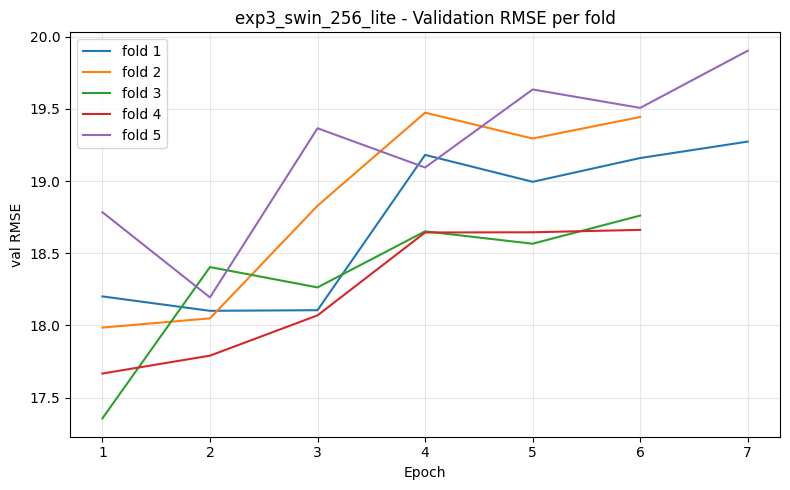

In [5]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="exp3_swin_256_lite")

In [6]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()


,Id,fold,ytrue,oof_pred,abs_err
0,054cef9194f1a4513dc0965893b589bf,3,2,85.123100,83.123100
1,d00e5d29d4ec09de1e0e0ebec41b2d03,1,5,85.826820,80.826820
2,ef7f96e35710c26e81f67ed29e967193,5,100,24.966415,75.033585
3,f4dd9ea389798d703ee5ebe2a82c8653,5,2,75.813454,73.813454
4,4435d6f98ad72782ca0cf61f946b016d,5,100,26.869101,73.130899


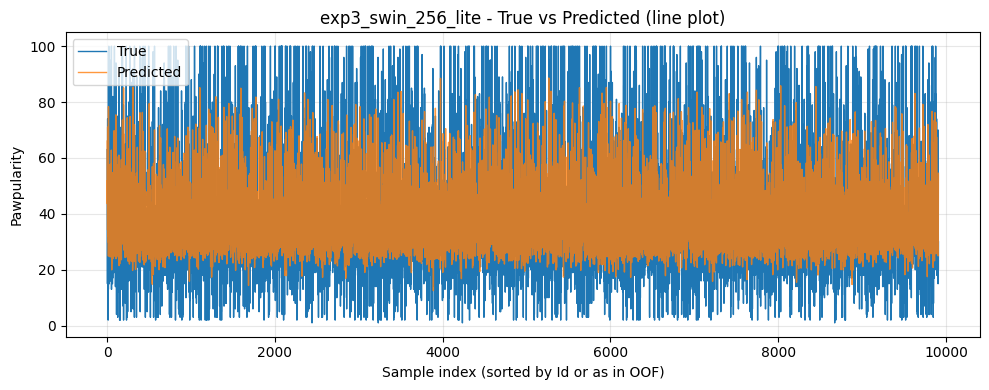

In [7]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="exp3_swin_256_lite")





Exp2_Eff_256_Lite_NoFusion OOF RMSE: 19.177387932516293
Exp3_Swin_256_Lite_NoFusion OOF RMSE: 17.863752509333363
ΔRMSE (Exp3_Swin_256_Lite_NoFusion - Exp2_Eff_256_Lite_NoFusion): -1.3136354231829301


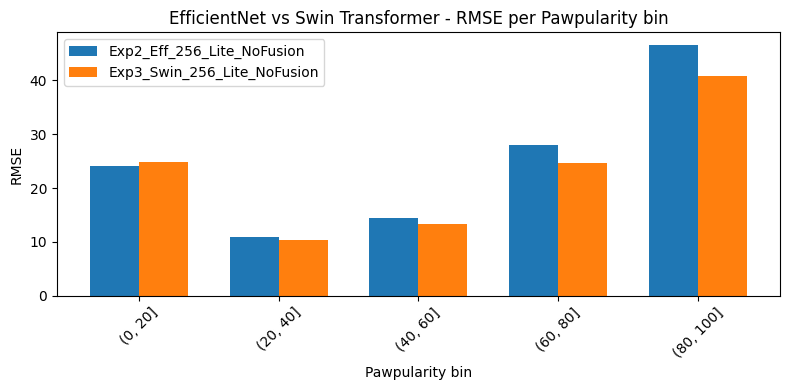

In [17]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a="../../outputs/exp2/oof_detail.csv",
    oof_path_b="../../outputs/extra/exp3_swin_256_lite/oof_detail.csv",
    bins=bins,
    label_a="Exp2_Eff_256_Lite_NoFusion",
    label_b="Exp3_Swin_256_Lite_NoFusion",
    title_prefix="EfficientNet vs Swin Transformer",
)

In [18]:
df_bins.head()

,bin,count,Exp2_Eff_256_Lite_NoFusion_rmse,Exp3_Swin_256_Lite_NoFusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.106148,24.803805,0.697657,Exp2_Eff_256_Lite_NoFusion_better
1,"(20, 40]",5119,10.851486,10.285063,-0.566424,Exp3_Swin_256_Lite_NoFusion_better
2,"(40, 60]",2088,14.386820,13.267305,-1.119515,Exp3_Swin_256_Lite_NoFusion_better
3,"(60, 80]",727,27.984539,24.725945,-3.258594,Exp3_Swin_256_Lite_NoFusion_better
4,"(80, 100]",561,46.588225,40.885352,-5.702873,Exp3_Swin_256_Lite_NoFusion_better


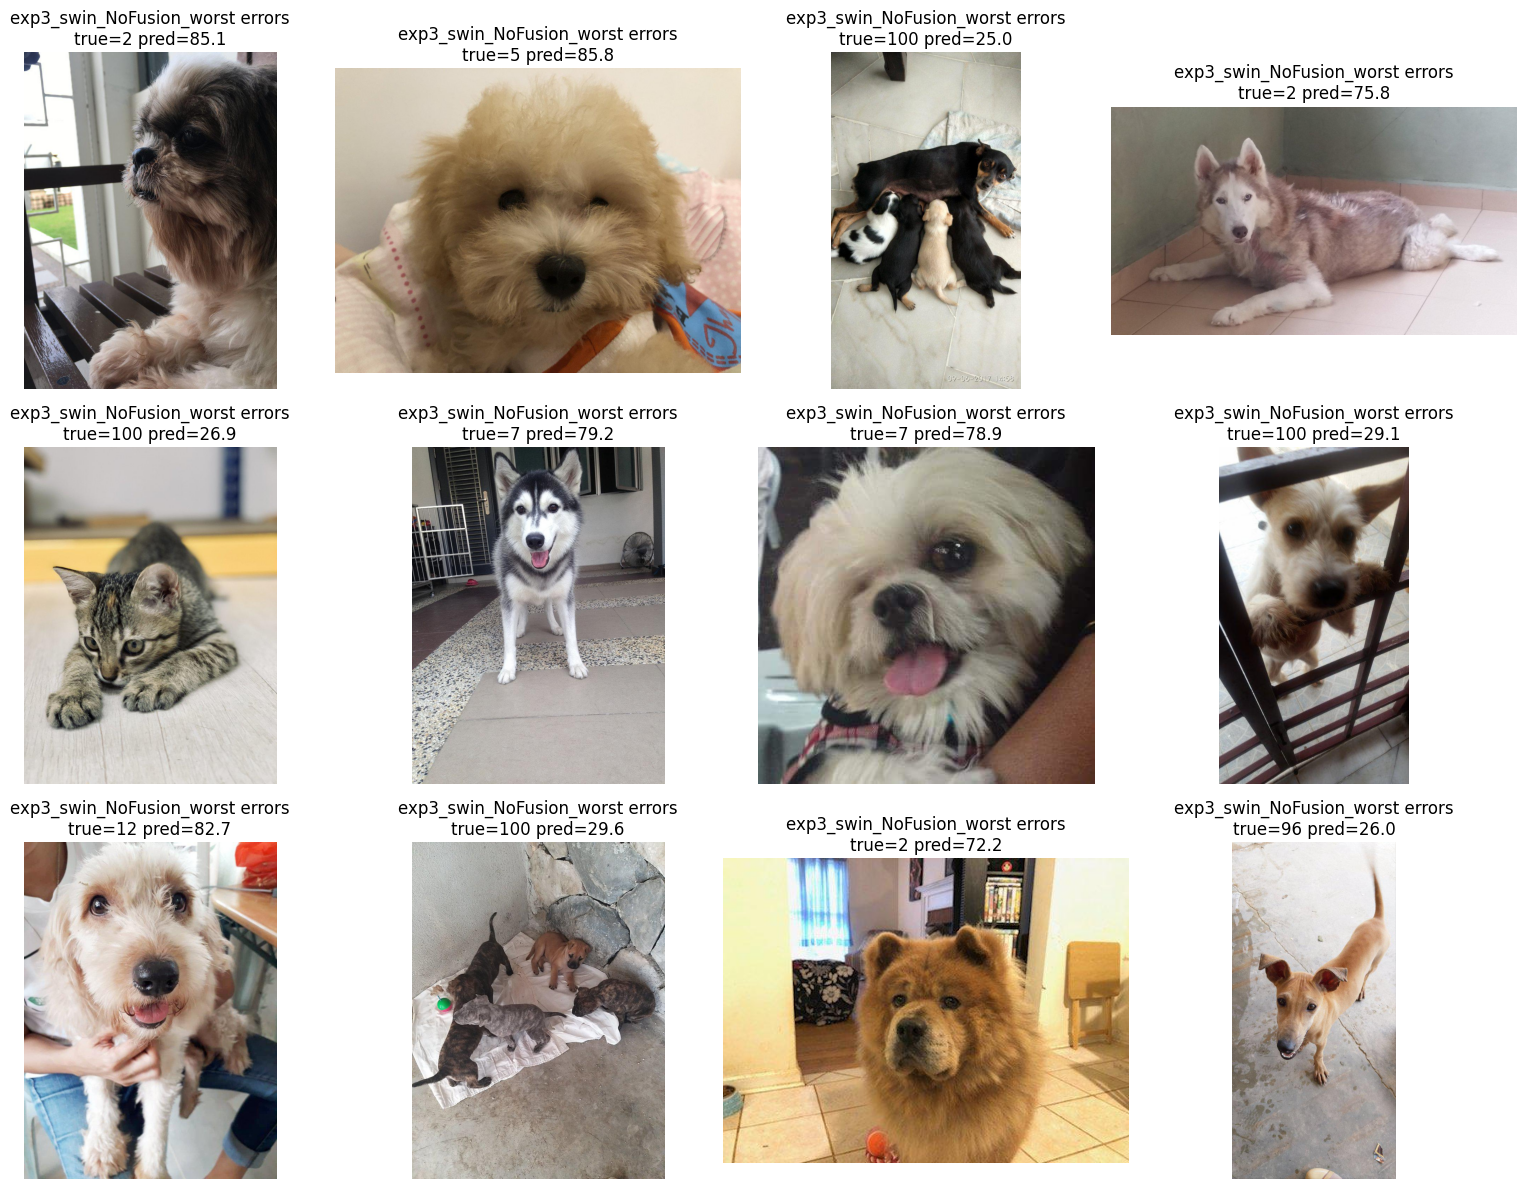

In [19]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp3_swin_NoFusion_worst errors")

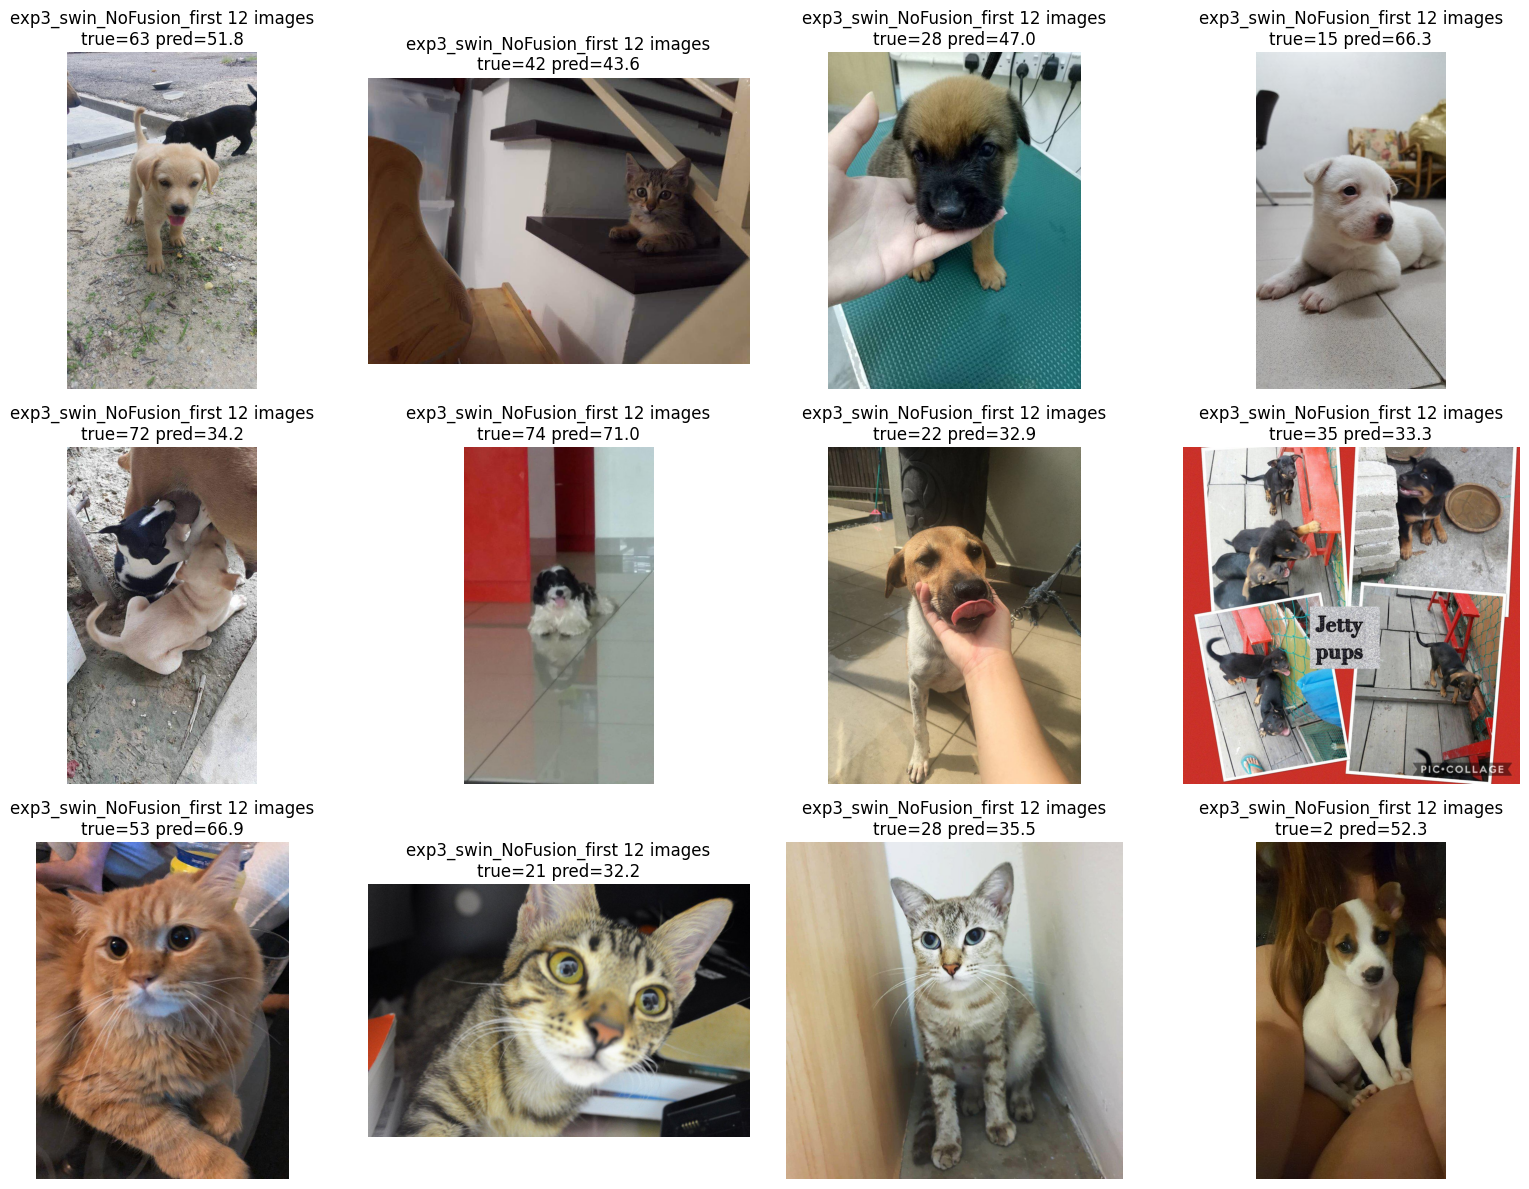

In [20]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(oof_df, img_folder, n=12, title_prefix="exp3_swin_NoFusion_first 12 images")